# Ames Housing – EDA, Preprocessing & SVR
> Predict house sale prices using Support Vector Regression with full preprocessing pipeline.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv(r'C:\Users\Abdulrahman\Desktop\PY.AI\NTI\ass3\AmesHousing.csv')
print(f'Shape: {df.shape}  |  Columns: {df.shape[1]}')
print(f'Numeric: {df.select_dtypes(include=np.number).shape[1]}  |  Categorical: {df.select_dtypes(include="object").shape[1]}')

Shape: (2930, 82)  |  Columns: 82
Numeric: 39  |  Categorical: 43


## 1. EDA – Identifying Issues

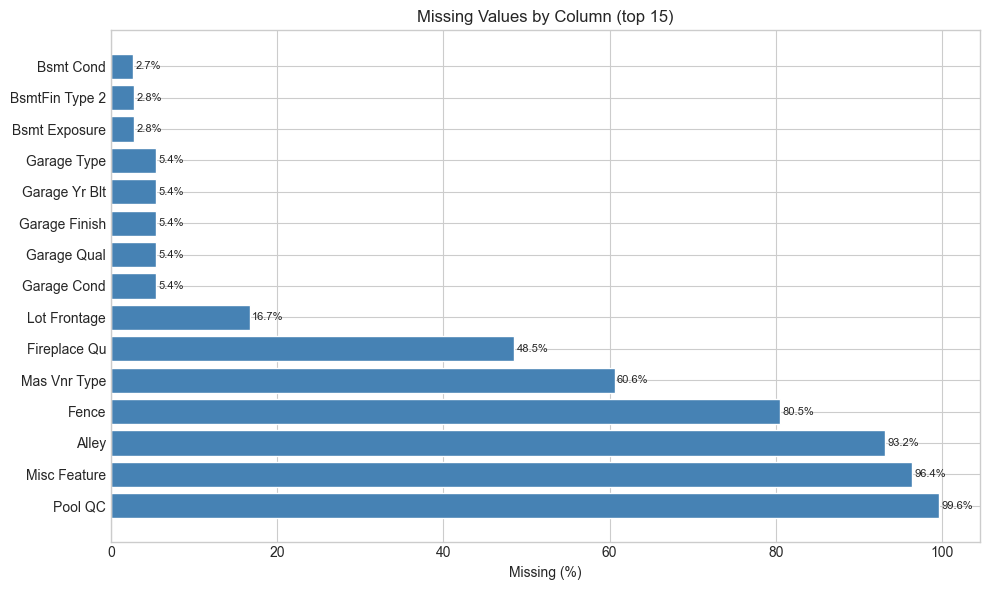

Note: Most NaN in Pool QC, Alley, Fence, Fireplace Qu mean the feature does NOT exist.


In [37]:
# Missing values overview
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(15)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing.index, missing_pct.values, color='steelblue', edgecolor='white')
for i, val in enumerate(missing_pct.values):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=8)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column (top 15)')
plt.tight_layout()
plt.show()

print('Note: Most NaN in Pool QC, Alley, Fence, Fireplace Qu mean the feature does NOT exist.')

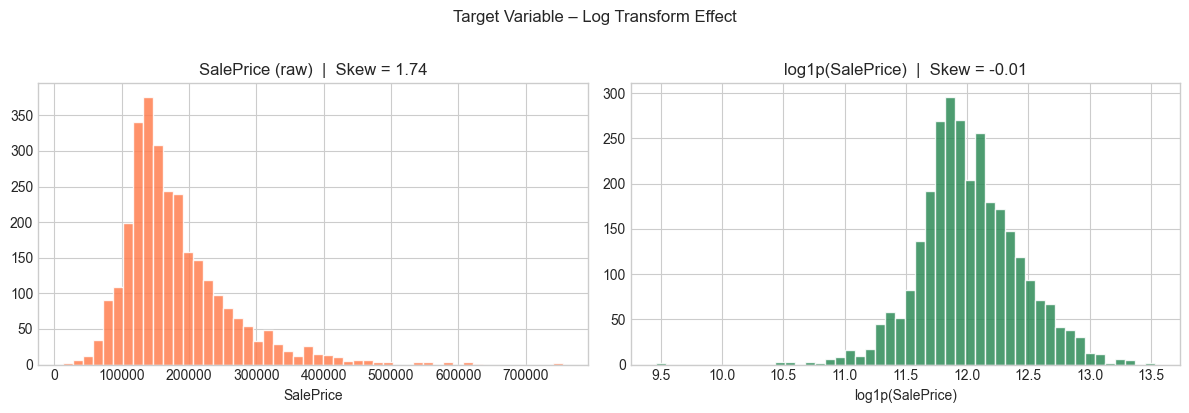

In [39]:
# SalePrice distribution – raw
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title(f'SalePrice (raw)  |  Skew = {df["SalePrice"].skew():.2f}')
axes[0].set_xlabel('SalePrice')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'log1p(SalePrice)  |  Skew = {np.log1p(df["SalePrice"]).skew():.2f}')
axes[1].set_xlabel('log1p(SalePrice)')

plt.suptitle('Target Variable – Log Transform Effect', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

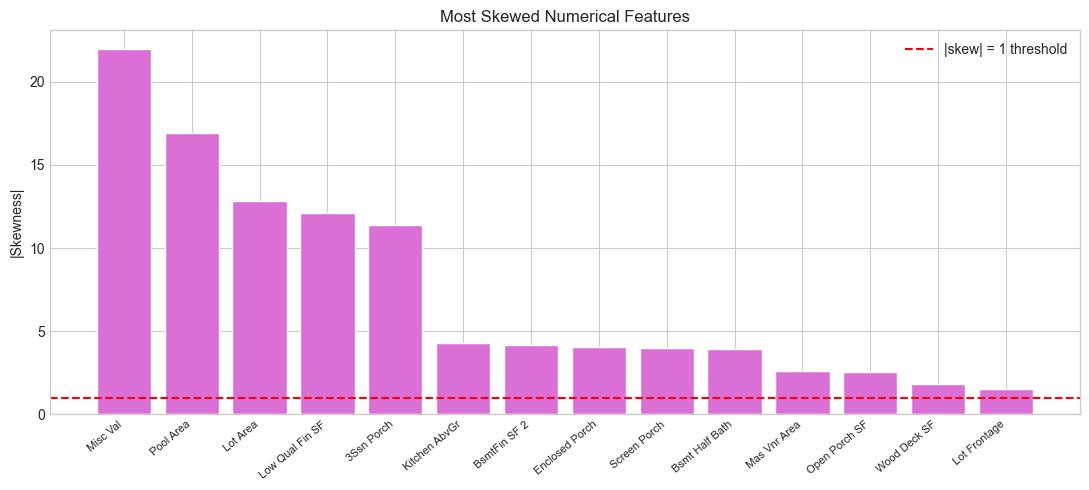

In [41]:
# Skewed numerical features
num_cols = df.select_dtypes(include=np.number).columns.drop(['Order','PID','SalePrice'])
skewness = df[num_cols].skew().abs().sort_values(ascending=False).head(14)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(skewness)), skewness.values, color='orchid', edgecolor='white')
ax.axhline(1, color='red', linestyle='--', label='|skew| = 1 threshold')
ax.set_xticks(range(len(skewness)))
ax.set_xticklabels(skewness.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('|Skewness|')
ax.set_title('Most Skewed Numerical Features')
ax.legend()
plt.tight_layout()
plt.show()

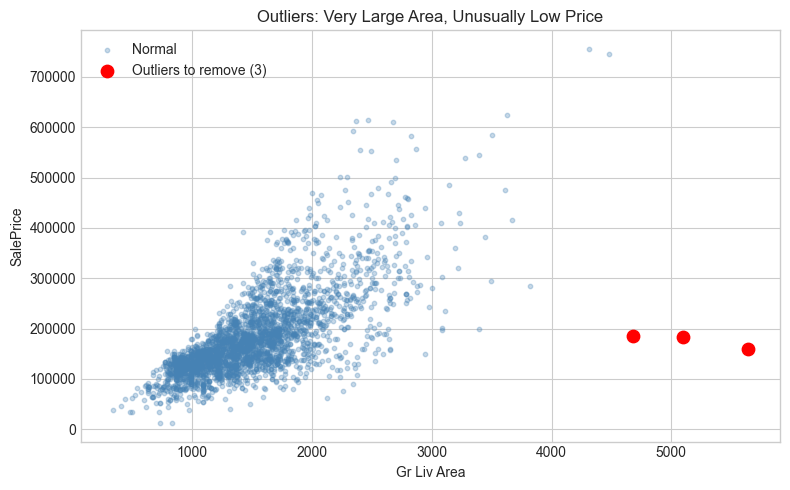

In [43]:
# Outliers: large Gr Liv Area with low price
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.3, s=10, color='steelblue', label='Normal')

outliers = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
ax.scatter(outliers['Gr Liv Area'], outliers['SalePrice'],
           color='red', s=80, zorder=5, label=f'Outliers to remove ({len(outliers)})')

ax.set_xlabel('Gr Liv Area')
ax.set_ylabel('SalePrice')
ax.set_title('Outliers: Very Large Area, Unusually Low Price')
ax.legend()
plt.tight_layout()
plt.show()

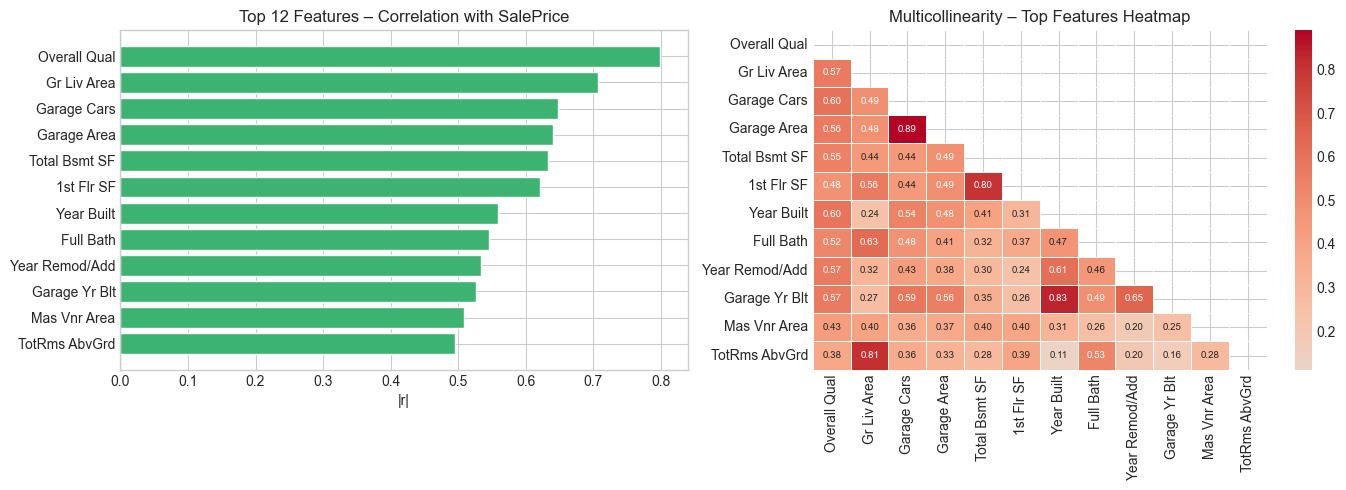

In [13]:
# Top correlations and multicollinearity
top_feats = df[num_cols.tolist() + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').abs()\
              .sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar of top correlations
corr_vals = df[top_feats + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').abs().sort_values()
axes[0].barh(corr_vals.index, corr_vals.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Top 12 Features – Correlation with SalePrice')
axes[0].set_xlabel('|r|')

# Heatmap for multicollinearity
cm = df[top_feats].corr()
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.4, annot_kws={'size': 7})
axes[1].set_title('Multicollinearity – Top Features Heatmap')

plt.tight_layout()
plt.show()

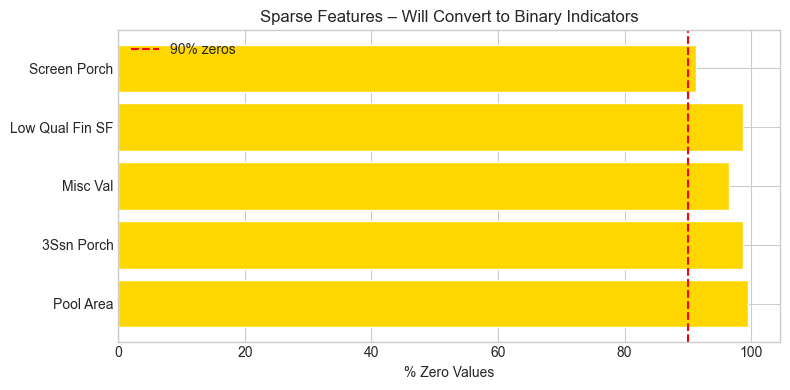

In [45]:
# Sparse features
sparse_cols = ['Pool Area', '3Ssn Porch', 'Misc Val', 'Low Qual Fin SF', 'Screen Porch']
zero_pct = {c: (df[c] == 0).mean() * 100 for c in sparse_cols}

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(zero_pct.keys()), list(zero_pct.values()), color='gold', edgecolor='white')
ax.axvline(90, color='red', linestyle='--', label='90% zeros')
ax.set_xlabel('% Zero Values')
ax.set_title('Sparse Features – Will Convert to Binary Indicators')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [47]:
# Drop non-informative ID columns
data = df.drop(columns=['Order', 'PID']).copy()

In [49]:
# NaN → 'None' where missing means the feature doesn't exist
none_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'Mas Vnr Type'
]
for col in none_cols:
    if col in data.columns:
        data[col] = data[col].fillna('None')

# NaN → median for numeric structural columns + Lot Frontage
median_fill = [
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars',
    'Garage Area', 'Mas Vnr Area', 'Lot Frontage'
]
for col in median_fill:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Catch-all: remaining numerics → median, categoricals → mode
for col in data.select_dtypes(include=np.number).columns:
    if data[col].isnull().any():
        data[col].fillna(data[col].median(), inplace=True)
for col in data.select_dtypes(include='object').columns:
    if data[col].isnull().any():
        data[col].fillna(data[col].mode()[0], inplace=True)

print(f'Missing values remaining: {data.isnull().sum().sum()}  ✓')

Missing values remaining: 0  ✓


In [51]:
# Remove extreme outliers: very large area, anomalously low price
before = len(data)
data = data[~((data['Gr Liv Area'] > 4000) & (data['SalePrice'] < 300_000))]
print(f'Removed {before - len(data)} outlier rows  |  Remaining: {len(data)}')

Removed 3 outlier rows  |  Remaining: 2927


In [53]:
# Feature engineering
data['TotalSF']      = data['Total Bsmt SF'] + data['1st Flr SF'] + data['2nd Flr SF']
data['HouseAge']     = data['Yr Sold'] - data['Year Built']
data['RemodAge']     = data['Yr Sold'] - data['Year Remod/Add']
data['TotalBath']    = (data['Full Bath'] + data['Bsmt Full Bath']
                        + 0.5 * (data['Half Bath'] + data['Bsmt Half Bath']))
data['TotalPorchSF'] = (data['Open Porch SF'] + data['Enclosed Porch']
                        + data['3Ssn Porch'] + data['Screen Porch'] + data['Wood Deck SF'])

# Binary indicators from sparse features
data['HasGarage']    = (data['Garage Area'] > 0).astype(int)
data['HasPool']      = (data['Pool Area'] > 0).astype(int)
data['HasFireplace'] = (data['Fireplaces'] > 0).astype(int)
data['Has2ndFloor']  = (data['2nd Flr SF'] > 0).astype(int)

print('Feature engineering complete.')

Feature engineering complete.


In [55]:
# Ordinal encoding – preserve ranking information
quality_map  = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
finish_map   = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
bsmtfin_map  = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

quality_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
                'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']
for col in quality_cols:
    data[col] = data[col].map(quality_map).fillna(0).astype(int)

data['Garage Finish']  = data['Garage Finish'].map(finish_map).fillna(0).astype(int)
data['Bsmt Exposure']  = data['Bsmt Exposure'].map(exposure_map).fillna(0).astype(int)
data['BsmtFin Type 1'] = data['BsmtFin Type 1'].map(bsmtfin_map).fillna(0).astype(int)
data['BsmtFin Type 2'] = data['BsmtFin Type 2'].map(bsmtfin_map).fillna(0).astype(int)
data['Land Slope']     = data['Land Slope'].map({'Gtl': 1, 'Mod': 2, 'Sev': 3}).fillna(1).astype(int)
data['Paved Drive']    = data['Paved Drive'].map({'N': 0, 'P': 1, 'Y': 2}).fillna(0).astype(int)

print('Ordinal encoding done.')

Ordinal encoding done.


In [57]:
# Log-transform skewed numerical features (|skew| > 0.75)
binary_indicator_cols = ['HasGarage', 'HasPool', 'HasFireplace', 'Has2ndFloor']
num_feats = data.select_dtypes(include=np.number).columns.drop('SalePrice')
skew_feats = [
    f for f in num_feats
    if abs(data[f].skew()) > 0.75 and f not in binary_indicator_cols
]
for col in skew_feats:
    data[col] = np.log1p(data[col].clip(lower=0))

# Log-transform target
data['SalePrice'] = np.log1p(data['SalePrice'])

print(f'log1p applied to {len(skew_feats)} features + SalePrice.')

log1p applied to 32 features + SalePrice.


In [59]:
# Drop redundant / near-zero-variance columns
drop_cols = [
    'Street',          # 99%+ Pave – no variance
    'Utilities',       # almost entirely AllPub
    'Condition 2',     # rare second condition
    'Roof Matl',       # rare values
    'Pool Area',       # replaced by HasPool
    'Misc Feature',    # mostly None
    'Misc Val',        # very sparse
    'Low Qual Fin SF', # very sparse
    '3Ssn Porch',      # very sparse, captured by TotalPorchSF
    'Garage Cars',     # highly correlated with Garage Area (r > 0.88)
    'Garage Yr Blt',   # redundant with HouseAge
    'Year Built',      # replaced by HouseAge
    'Year Remod/Add',  # replaced by RemodAge
]
data.drop(columns=[c for c in drop_cols if c in data.columns], inplace=True)

print(f'Columns remaining: {data.shape[1]}')

Columns remaining: 76


In [61]:
print(f'Final shape: {data.shape}  |  Nulls: {data.isnull().sum().sum()}')

Final shape: (2927, 76)  |  Nulls: 0


In [63]:
# =========================
# Target Encoding (بديل One-Hot)
# =========================

import pandas as pd

# فصل target
y = data['SalePrice']
X = data.drop(columns=['SalePrice'])

# الأعمدة الكاتيجوريكال
cat_cols = X.select_dtypes(include='object').columns

# Apply Target Encoding
for col in cat_cols:
    target_mean = X.groupby(col)[col].transform('count')  # dummy step to align index
    means = data.groupby(col)['SalePrice'].mean()
    X[col] = X[col].map(means)

# Fill any missing (لو فيه category جديدة)
X.fillna(X.mean(), inplace=True)

print("Target Encoding done ✅")
print("Shape:", X.shape)

Target Encoding done ✅
Shape: (2927, 75)


## 3. Post-Preprocessing Visualizations

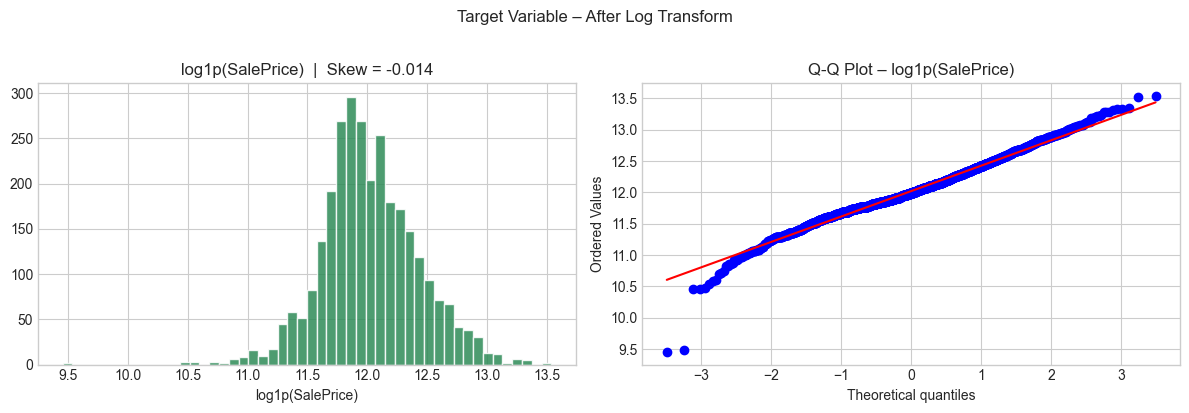

In [65]:
# Target variable after log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['SalePrice'], bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_title(f'log1p(SalePrice)  |  Skew = {data["SalePrice"].skew():.3f}')
axes[0].set_xlabel('log1p(SalePrice)')

stats.probplot(data['SalePrice'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot – log1p(SalePrice)')

plt.suptitle('Target Variable – After Log Transform', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

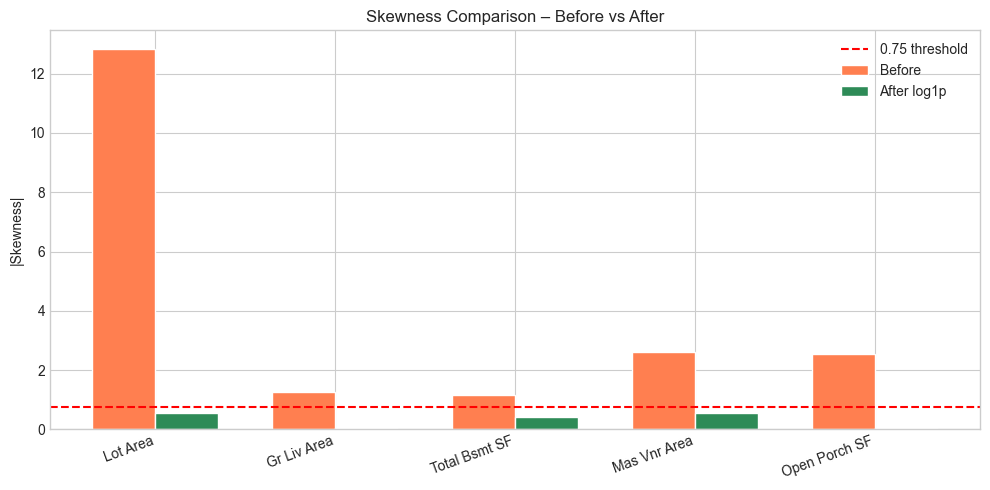

In [67]:
# Skewness before vs after for key features
key = ['Lot Area', 'Gr Liv Area', 'Total Bsmt SF', 'Mas Vnr Area', 'Open Porch SF']
before_s = df[key].skew().abs()
after_s  = data[[f for f in key if f in data.columns]].skew().abs()

x = np.arange(len(before_s))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, before_s.values, w, label='Before', color='coral', edgecolor='white')
ax.bar(x + w/2, after_s.reindex(before_s.index).values, w, label='After log1p', color='seagreen', edgecolor='white')
ax.axhline(0.75, color='red', linestyle='--', label='0.75 threshold')
ax.set_xticks(x)
ax.set_xticklabels(before_s.index, rotation=20, ha='right')
ax.set_title('Skewness Comparison – Before vs After')
ax.set_ylabel('|Skewness|')
ax.legend()
plt.tight_layout()
plt.show()

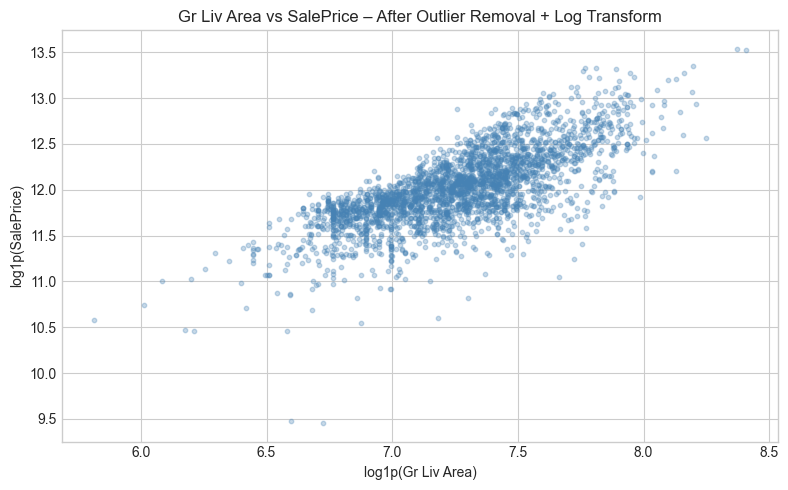

In [69]:
# Scatter after outlier removal
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data['Gr Liv Area'], data['SalePrice'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('log1p(Gr Liv Area)')
ax.set_ylabel('log1p(SalePrice)')
ax.set_title('Gr Liv Area vs SalePrice – After Outlier Removal + Log Transform')
plt.tight_layout()
plt.show()

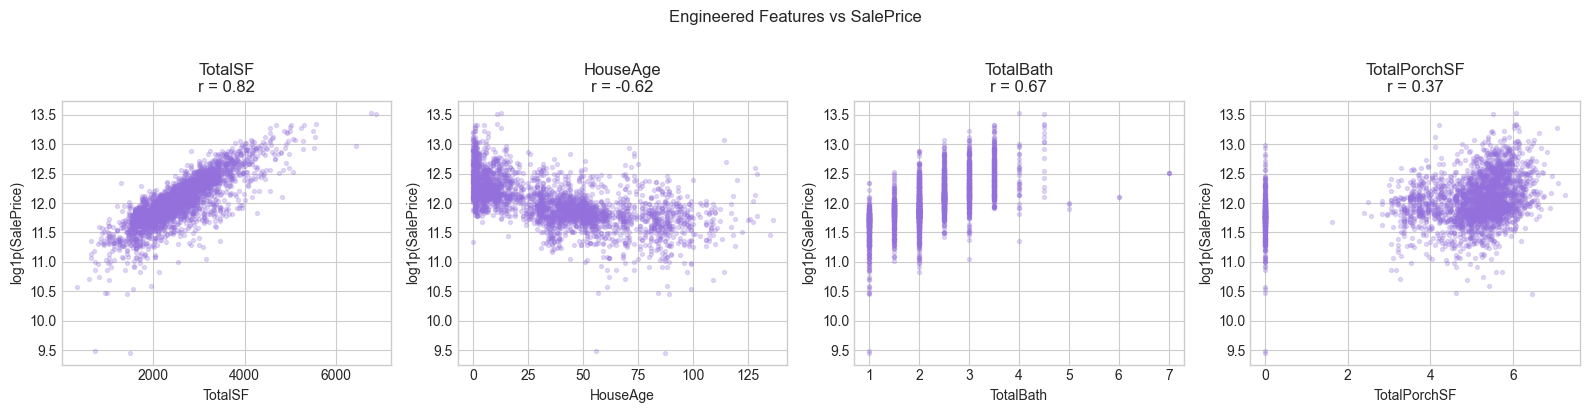

In [71]:
# Engineered features vs SalePrice
eng_feats = ['TotalSF', 'HouseAge', 'TotalBath', 'TotalPorchSF']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, eng_feats):
    r = data[[feat, 'SalePrice']].corr().iloc[0, 1]
    ax.scatter(data[feat], data['SalePrice'], alpha=0.25, s=8, color='mediumpurple')
    ax.set_xlabel(feat)
    ax.set_ylabel('log1p(SalePrice)')
    ax.set_title(f'{feat}\nr = {r:.2f}')
plt.suptitle('Engineered Features vs SalePrice', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. SVR Model

In [73]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (2341, 75)  |  Test: (586, 75)


In [77]:
X_train = X_train.select_dtypes(include=['number'])
X_test  = X_test.select_dtypes(include=['number'])

In [79]:
# Scale features – critical for SVR (RBF kernel uses Euclidean distances)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [81]:
# Hyperparameter search
param_grid = {
    'C':       [1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1],
    'gamma':   ['scale', 'auto']
}

gs = GridSearchCV(
    SVR(kernel='rbf'), param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
gs.fit(X_train_scaled, y_train)

print('Best params :', gs.best_params_)
print(f'Best CV RMSE: {-gs.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params : {'C': 1, 'epsilon': 0.01, 'gamma': 'auto'}
Best CV RMSE: 0.1494


In [83]:
best_svr = gs.best_estimator_
y_pred   = best_svr.predict(X_test_scaled)

rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
mae      = mean_absolute_error(y_test, y_pred)
r2       = r2_score(y_test, y_pred)

# Back to original USD scale
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred)
rmse_usd   = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

print('========== Test Set Results ==========')
print(f'R²               : {r2:.4f}')
print(f'RMSE (log scale) : {rmse:.4f}')
print(f'MAE  (log scale) : {mae:.4f}')
print(f'RMSE (USD)       : ${rmse_usd:,.0f}')
print('======================================')

========== Test Set Results ==========
R²               : 0.9251
RMSE (log scale) : 0.1160
MAE  (log scale) : 0.0825
RMSE (USD)       : $26,648


In [85]:
# Cross-validation on training set
cv_scores = cross_val_score(best_svr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'CV R² scores : {np.round(cv_scores, 4)}')
print(f'Mean R²      : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')

CV R² scores : [0.8683 0.8979 0.8084 0.8719 0.8646]
Mean R²      : 0.8622  ±  0.0294


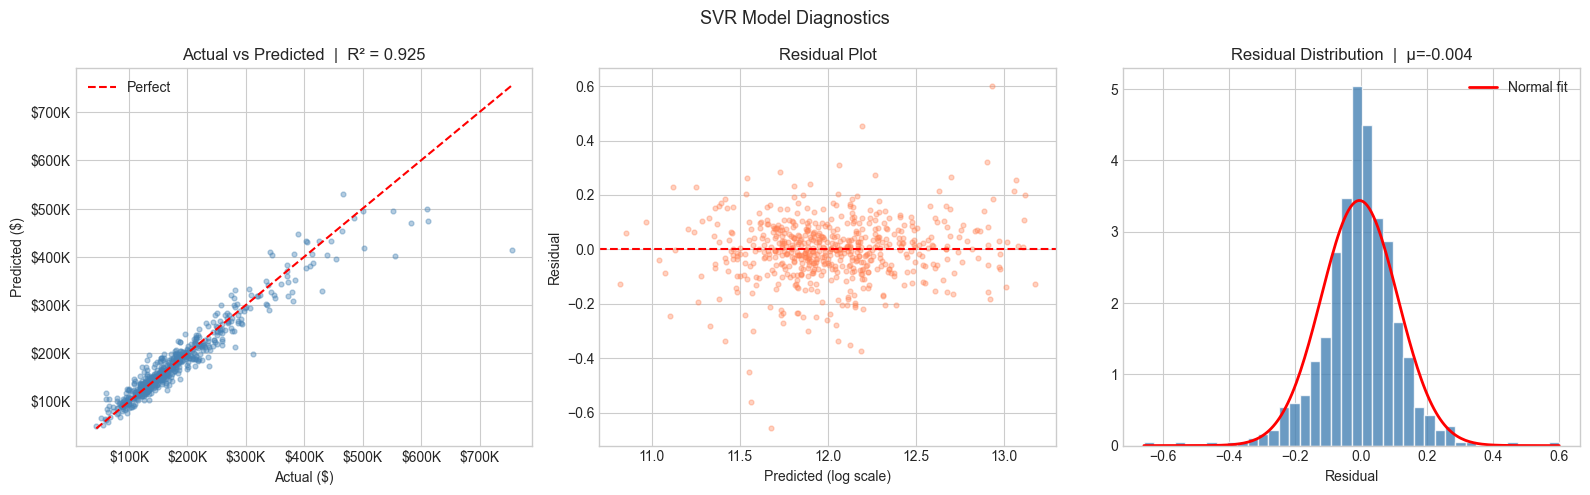

In [87]:
# Model diagnostics
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SVR Model Diagnostics', fontsize=13)

# Actual vs Predicted
mn, mx = y_test_usd.min(), y_test_usd.max()
axes[0].scatter(y_test_usd, y_pred_usd, alpha=0.4, s=12, color='steelblue')
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].set_title(f'Actual vs Predicted  |  R² = {r2:.3f}')
axes[0].legend()
fmt = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
axes[0].xaxis.set_major_formatter(fmt)
axes[0].yaxis.set_major_formatter(fmt)

# Residuals vs Fitted
axes[1].scatter(y_pred, residuals, alpha=0.35, s=12, color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted (log scale)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

# Residual distribution
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', density=True, alpha=0.8)
x_r = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_r, stats.norm.pdf(x_r, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label=f'Normal fit')
axes[2].set_xlabel('Residual')
axes[2].set_title(f'Residual Distribution  |  μ={residuals.mean():.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [89]:
# Final summary
print('╔══════════════════════════════════╗')
print('║        SVR Final Summary         ║')
print('╠══════════════════════════════════╣')
print(f'║  Kernel    : RBF                 ║')
print(f'║  C         : {gs.best_params_["C"]:<21}║')
print(f'║  Epsilon   : {gs.best_params_["epsilon"]:<21}║')
print(f'║  Gamma     : {gs.best_params_["gamma"]:<21}║')
print('╠══════════════════════════════════╣')
print(f'║  Test R²   : {r2:.4f}               ║')
print(f'║  RMSE USD  : ${rmse_usd:,.0f}           ║')
print(f'║  CV R²     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}    ║')
print('╚══════════════════════════════════╝')

╔══════════════════════════════════╗
║        SVR Final Summary         ║
╠══════════════════════════════════╣
║  Kernel    : RBF                 ║
║  C         : 1                    ║
║  Epsilon   : 0.01                 ║
║  Gamma     : auto                 ║
╠══════════════════════════════════╣
║  Test R²   : 0.9251               ║
║  RMSE USD  : $26,648           ║
║  CV R²     : 0.8622 ± 0.0294    ║
╚══════════════════════════════════╝
